# Single Trajectory Optimization

In [26]:
import sys
import os
import yaml
import time
import numpy as np
import matplotlib.pyplot as plt
from rocketpy import Flight, Environment
import random
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Setup path for custom modules
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
sys.path.append(parent_dir)

# Import custom modules
try:
    from simulation.rocket_factory import RocketFactory
    from simulation.trajectory_evaluation import TrajectoryEvaluator
    from optimizer.ACO_R import ContinuousACO
    print("Modules imported successfully.")
except ImportError as e:
    print(f"Import error: {e}")
    print("Make sure to run the notebook from the 'notebooks/' folder and that the 'simulation' and 'optimizer' folders exist.")

Modules imported successfully.


In [ ]:
# Configuration file paths
CONSTRAINTS_FILE = "../config/missile_constraints.yaml"
ACO_PARAMS_FILE = "../config/optimization_parameters.yaml" 

# Load YAML files
with open(CONSTRAINTS_FILE, 'r') as f:
    missile_config = yaml.safe_load(f)


with open(ACO_PARAMS_FILE, 'r') as f:
    aco_config = yaml.safe_load(f)


# Extract useful data
golden_params = missile_config['golden_rocket']
bounds = missile_config['design_variables']
max_calls = aco_config['general']['max_function_calls']


print("Configuration loaded.")
print(f" Golden Rocket Impulse: {golden_params['total_impulse']} Ns")
print(f" Max Function Calls: {max_calls}")

Configuration loaded.
 Golden Rocket Impulse: 3200.0 Ns
 Max Function Calls: 4000


In [3]:
# Load seed from config
seed_val = aco_config['general']['random_seed']

# Set seed for all random number generators
random.seed(seed_val)
np.random.seed(seed_val)


print(f"Random seed set to: {seed_val}")

Random seed set to: 42


In [ ]:
# Initialize Factory and Evaluator
factory = RocketFactory()
evaluator = TrajectoryEvaluator(CONSTRAINTS_FILE)

# Create Golden Rocket
golden_rocket = factory.create_rocket(golden_params)

# 1. Create the Environment (Spaceport America)
env = Environment(
    latitude=32.990254,
    longitude=-106.974998,
    elevation=1400 # meters above sea level
)


tomorrow = datetime.date.today() + datetime.timedelta(days=1)
env.set_date((tomorrow.year, tomorrow.month, tomorrow.day, 12)) # noon
env.set_atmospheric_model(type="standard_atmosphere")

# Simulate Golden flight (for plotting)
print("Simulating Golden Rocket flight...")
golden_flight = Flight(
    rocket=golden_rocket,
    environment=env,
    rail_length=factory.rail_length,
    inclination=golden_params['launch_angle'],
    heading=90,
    terminate_on_apogee=False
)

# Extract data for plotting (target trajectory)
golden_alt = golden_flight.z[:, 1] - env.elevation
# Horizontal range at each time step
golden_range = np.sqrt(golden_flight.x[:, 1]**2 + golden_flight.y[:, 1]**2)


print("Golden Rocket simulated.")
print(f" Target Apogee: {golden_flight.apogee - env.elevation:.2f} m")
print(f" Target Range: {golden_range[-1]:.2f} m")

Simulating Golden Rocket flight...
Golden Rocket simulated.
 Target Apogee: 1322.34 m
 Target Range: 615.61 m


In [5]:
# global counter to monitor progress
call_counter = 0

def fitness_function(params):
    global call_counter
    call_counter += 1
    
    # 1. Create rocket
    try:
        rocket = factory.create_rocket(params)
    except Exception:
        return 10000.0 
        
    # 2. Preliminary stability check (safety)
    try:
        if rocket.static_margin(0) < 0:
            return 10000.0
    except:
        return 10000.0
        
    # 3. Simulation and evaluation
    # Launch angle is an optimization parameter for the 'single' task
    launch_angle = params['launch_angle']
    
    # Use evaluator's internal method to simulate
    flight_data = evaluator._simulate_flight(rocket, launch_angle)
    
    # Compute fitness with respect to config targets
    fitness = evaluator.evaluate(flight_data, task_type='single')
    
    # Print progress every 500 calls
    #if call_counter % 500 == 0:
        #print(f"   Iter: {call_counter} | Current Fit: {fitness:.4f}")
        
    return fitness

print("Wrapper Fitness defined.")

Wrapper Fitness defined.


## ACO-R

In [6]:
print(f"Starting ACO-R optimization (Budget: {max_calls} calls)...")
start_time = time.time()


# 1. Initialize algorithm
# Generates the initial random archive (costs k fitness calls)
optimizer = ContinuousACO(ACO_PARAMS_FILE, CONSTRAINTS_FILE)
optimizer.initialize(fitness_function)


# Save random start (best of initialization)
random_best_params, random_best_fit = optimizer.get_best_solution()


print(f" Initial Fitness (Best Random): {random_best_fit:.4f}")
print(" Random start parameters saved for final comparison.")


# 2. Main loop
best_fitness_history = []


# Call counter starts from k (initial archive size)
call_counter = optimizer.k
iteration = 0


while call_counter < max_calls:
    iteration += 1
    # Perform one optimization step
    # Generates 'm' new ants, evaluates them and updates the archive
    best_fit = optimizer.optimize_step(fitness_function)
    best_fitness_history.append(best_fit)
    # Update the call counter (each ACO step generates self.m new solutions)
    call_counter += optimizer.m
    # Debug print every 50 iterations
    if iteration % 50 == 0:
        print(f"Calls: {call_counter:5d}/{max_calls} | Current Best Fitness: {best_fit:.4f}")


execution_time = time.time() - start_time
print(f"\nOptimization completed in {execution_time:.2f} seconds.")

Starting ACO-R optimization (Budget: 4000 calls)...
 Initial Fitness (Best Random): 36.5037
 Random start parameters saved for final comparison.
Calls:   250/4000 | Current Best Fitness: 4.8507
Calls:   450/4000 | Current Best Fitness: 2.9348
Calls:   650/4000 | Current Best Fitness: 2.9140
Calls:   850/4000 | Current Best Fitness: 2.9140
Calls:  1050/4000 | Current Best Fitness: 2.2575
Calls:  1250/4000 | Current Best Fitness: 1.3555
Calls:  1450/4000 | Current Best Fitness: 0.9112
Calls:  1650/4000 | Current Best Fitness: 0.9112
Calls:  1850/4000 | Current Best Fitness: 0.9112
Calls:  2050/4000 | Current Best Fitness: 0.9112
Calls:  2250/4000 | Current Best Fitness: 0.9112
Calls:  2450/4000 | Current Best Fitness: 0.9112
Calls:  2650/4000 | Current Best Fitness: 0.7572
Calls:  2850/4000 | Current Best Fitness: 0.7572
Calls:  3050/4000 | Current Best Fitness: 0.7572
Calls:  3250/4000 | Current Best Fitness: 0.4651
Calls:  3450/4000 | Current Best Fitness: 0.4651
Calls:  3650/4000 | Cu

In [7]:
best_params, best_score = optimizer.get_best_solution()


print(f"BEST SOLUTION FOUND (Fitness: {best_score:.4f})")
for key, val in best_params.items():
    print(f" {key}: {val:.4f}")

# Create optimized rocket
best_rocket = factory.create_rocket(best_params)

# Simulate optimized flight
print("\nSimulating optimized rocket flight...")
best_flight = Flight(
    rocket=best_rocket,
    environment=evaluator.env, # same environment (includes wind)
    rail_length=factory.rail_length,
    inclination=best_params['launch_angle'],
    heading=90,
    terminate_on_apogee=False
)

# Extract data for plotting
best_alt = best_flight.z[:, 1] - evaluator.env.elevation
best_range = np.sqrt(best_flight.x[:, 1]**2 + best_flight.y[:, 1]**2)

print(f" Best Apogee: {best_flight.apogee - evaluator.env.elevation:.2f} m")
print(f" Best Range: {best_range[-1]:.2f} m")

BEST SOLUTION FOUND (Fitness: 0.4651)
 radius: 0.0601
 body_length: 2.1250
 nose_length: 0.6371
 fin_span: 0.2491
 fin_root_chord: 0.4502
 fin_tip_chord: 0.1638
 fin_sweep_angle: 37.5986
 fin_distance_from_base: 0.0464
 total_impulse: 3141.1985
 burn_time: 4.3665
 launch_angle: 84.9825

Simulating optimized rocket flight...
 Best Apogee: 1324.07 m
 Best Range: 616.41 m


In [10]:
# Retrieve real data
# 1. golden_params (Target)
# 2. random_best_params (Best initial sample)
# 3. best_params (Optimized solution)

data = []

# Iterate over keys from the optimal solution
param_keys = list(best_params.keys())


for key in param_keys:
    # Target value (Golden Rocket)
    val_golden = golden_params.get(key, 0.0)

    # Optimized value (ACO result)
    val_opt = best_params.get(key, 0.0)

    # Random start value (best from initial population)
    val_rnd = random_best_params.get(key, 0.0)

    # Percentage deviation of optimized vs target
    if val_golden != 0:
        dev_perc = ((val_opt - val_golden) / val_golden) * 100
    else:
        dev_perc = 0.0

    data.append({
        "Parameter": key,
        "Target (Golden)": val_golden,
        "Random Start": val_rnd,
        "Optimized (ACO)": val_opt,
        "Deviation %": dev_perc
    })

# Create DataFrame
df_params = pd.DataFrame(data)

# Set global formatting for clean float display
pd.options.display.float_format = '{:,.4f}'.format


print("DETAILED PARAMETER ANALYSIS")
print("-" * 80)

display(df_params)

# Text summary
print("-" * 80)
print("RESULTS COMMENTARY:")
print(" - Random Start: Shows the best random starting point found during initialization.")
print(" - Deviation %: Indicates how close ACO moved toward the 'hidden' Golden Rocket values.")
print(" * Values near 0% indicate the parameter was correctly identified.")
print(" * High values may indicate that the algorithm found an alternative valid configuration (non-unique solution).")

DETAILED PARAMETER ANALYSIS
--------------------------------------------------------------------------------


,Parameter,Target (Golden),Random Start,Optimized (ACO),Deviation %
0,radius,0.0650,0.0634,0.0601,-7.5436
1,body_length,2.1000,2.3840,2.1250,1.1928
2,nose_length,0.6500,0.5497,0.6371,-1.9825
3,fin_span,0.1800,0.1556,0.2491,38.3765
4,fin_root_chord,0.3500,0.4438,0.4502,28.6331
5,fin_tip_chord,0.1200,0.2394,0.1638,36.4593
6,fin_sweep_angle,30.0000,44.5100,37.5986,25.3287
7,fin_distance_from_base,0.0000,0.0377,0.0464,0.0000
8,total_impulse,"3,200.0000","3,128.7788","3,141.1985",-1.8375
9,burn_time,4.5000,2.3340,4.3665,-2.9677


--------------------------------------------------------------------------------
RESULTS COMMENTARY:
 - Random Start: Shows the best random starting point found during initialization.
 - Deviation %: Indicates how close ACO moved toward the 'hidden' Golden Rocket values.
 * Values near 0% indicate the parameter was correctly identified.
 * High values may indicate that the algorithm found an alternative valid configuration (non-unique solution).


### ACO-R + LS

In [11]:
try:
    from optimizer.nelder_mead import NelderMeadSimplex
    print("Nelder-Mead module loaded successfully.")
except ImportError:
    print("Error: Nelder-Mead module not found.")

print("\nStarting Fine Tuning with Local Search (Nelder-Mead)...")
ls_start_time = time.time()

# 1. Local Search Configuration
# Load parameters defined in the YAML configuration file
ls_config = aco_config['local_search']
ls_engine = NelderMeadSimplex(optimizer, ls_config)

# 2. Define Starting Point
# Use the best solution found by ACO as the initial vertex for the Simplex
aco_best_vector = optimizer.archive_X[0]
aco_best_fitness = optimizer.archive_F[0]

print(f"   Input Fitness (from ACO-R): {aco_best_fitness:.5f}")

# 3. Execute Simplex Search
# Note: fitness_function continues to increment the global call counter
ls_best_vector, ls_best_fitness = ls_engine.search(aco_best_vector, fitness_function)

# 4. Parse Results
# Convert the resulting numpy vector back into a parameter dictionary
ls_best_params = dict(zip(optimizer.var_names, ls_best_vector))

ls_time = time.time() - ls_start_time
print(f"Local Search completed in {ls_time:.2f} s.")
print(f"   Initial Fitness: {aco_best_fitness:.5f}")
print(f"   Final Fitness:   {ls_best_fitness:.5f}")

# Calculate percentage improvement
improvement = ((aco_best_fitness - ls_best_fitness) / aco_best_fitness) * 100
print(f"   Improvement: {improvement:.2f}%")

Nelder-Mead module loaded successfully.

Starting Fine Tuning with Local Search (Nelder-Mead)...
   Input Fitness (from ACO-R): 0.46511
Local Search completed in 124.30 s.
   Initial Fitness: 0.46511
   Final Fitness:   0.19241
   Improvement: 58.63%


In [12]:
print("\n" + "="*50)
print(f"BEST SOLUTION FOUND (ACO-R + Local Search)")
print("="*50)
print(f"Final Fitness: {ls_best_fitness:.6f}")
print("-" * 50)
print(f"{'PARAMETER':<25} | {'VALUE':<15}")
print("-" * 50)

for key, val in ls_best_params.items():
    print(f"{key:<25} | {val:.4f}")

print("="*50)


BEST SOLUTION FOUND (ACO-R + Local Search)
Final Fitness: 0.192412
--------------------------------------------------
PARAMETER                 | VALUE          
--------------------------------------------------
radius                    | 0.0601
body_length               | 2.1257
nose_length               | 0.6441
fin_span                  | 0.2490
fin_root_chord            | 0.4503
fin_tip_chord             | 0.1643
fin_sweep_angle           | 37.7994
fin_distance_from_base    | 0.0468
total_impulse             | 3142.6857
burn_time                 | 4.3920
launch_angle              | 85.0111


In [13]:
golden_params = missile_config['golden_rocket']
aco_params, _ = optimizer.get_best_solution()

# Target simulation 
golden_rocket = factory.create_rocket(golden_params)
flight_golden = Flight(rocket=golden_rocket, environment=evaluator.env, rail_length=factory.rail_length, 
                       inclination=golden_params['launch_angle'], heading=90, terminate_on_apogee=False)
data_golden = {'x': flight_golden.x[:,1], 'z': flight_golden.z[:,1]}

# ACO-R simulation
rocket_aco = factory.create_rocket(aco_params)
flight_aco = Flight(rocket=rocket_aco, environment=evaluator.env, rail_length=factory.rail_length, 
                    inclination=aco_params['launch_angle'], heading=90, terminate_on_apogee=False)
data_aco = {'x': flight_aco.x[:,1], 'z': flight_aco.z[:,1]}

# ACO-R + LS simulation
rocket_ls = factory.create_rocket(ls_best_params)
flight_ls = Flight(rocket=rocket_ls, environment=evaluator.env, rail_length=factory.rail_length, 
                   inclination=ls_best_params['launch_angle'], heading=90, terminate_on_apogee=False)
data_ls = {'x': flight_ls.x[:,1], 'z': flight_ls.z[:,1]}

In [14]:
def get_range_profile(flight_obj):

    return np.sqrt(flight_obj.x[:,1]**2 + flight_obj.y[:,1]**2)

r_golden = get_range_profile(flight_golden)
z_golden = flight_golden.z[:, 1] - evaluator.env.elevation

r_aco = get_range_profile(flight_aco)
z_aco = flight_aco.z[:, 1] - evaluator.env.elevation

r_ls = get_range_profile(flight_ls)
z_ls = flight_ls.z[:, 1] - evaluator.env.elevation

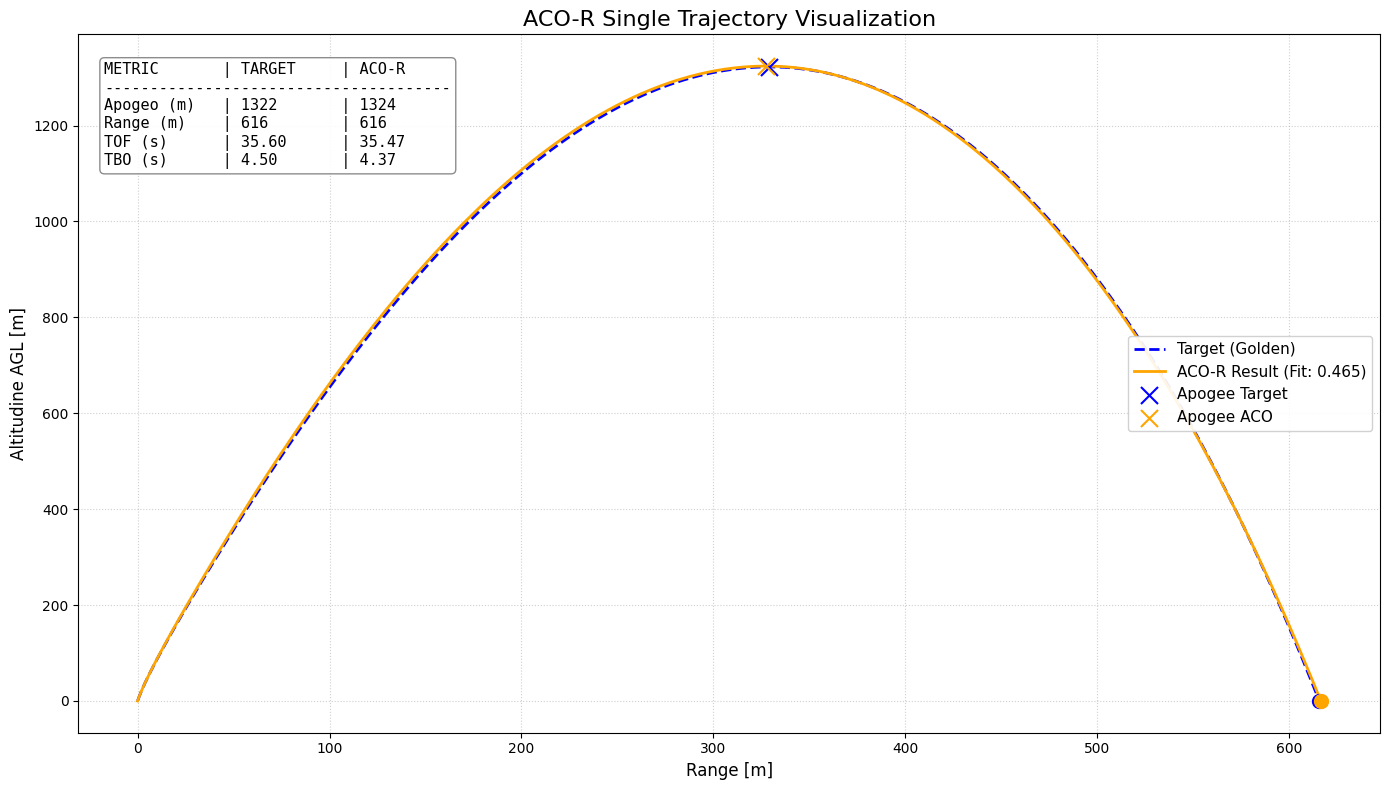

In [17]:
# Target (Golden)
val_tof_target = flight_golden.t_final
val_tbo_target = golden_params['burn_time']
val_apogee_target = np.max(z_golden)
val_range_target = r_golden[-1]

#(ACO-R)
val_tof_aco = flight_aco.t_final
val_tbo_aco = aco_params['burn_time'] # best_params['burn_time']
val_apogee_aco = np.max(z_aco)
val_range_aco = r_aco[-1]

idx_apogee_golden = np.argmax(z_golden)
xy_apogee_golden = (r_golden[idx_apogee_golden], val_apogee_target)

idx_apogee_aco = np.argmax(z_aco)
xy_apogee_aco = (r_aco[idx_apogee_aco], val_apogee_aco)

plt.figure(figsize=(14, 8))
plt.plot(r_golden, z_golden, 'b--', linewidth=2, label='Target (Golden)')
plt.plot(r_aco, z_aco, color='orange', linewidth=2, label=f'ACO-R Result (Fit: {aco_best_fitness:.3f})')
plt.scatter(*xy_apogee_golden, color='blue', s=150, marker='x', zorder=5, label='Apogee Target')
plt.scatter(*xy_apogee_aco, color='orange', s=150, marker='x', zorder=5, label='Apogee ACO')

#plt.annotate(f"{val_apogee_target:.0f}m", xy=xy_apogee_golden, xytext=(0, 10), 
             #textcoords="offset points", ha='center', color='blue')
#plt.annotate(f"{val_apogee_aco:.0f}m", xy=xy_apogee_aco, xytext=(0, 10), 
             #textcoords="offset points", ha='center', color='darkorange')

plt.scatter(val_range_target, 0, color='blue', s=100, marker='o', zorder=5)
plt.scatter(val_range_aco, 0, color='orange', s=100, marker='o', zorder=5)

stats_text = (
    f"{'METRIC':<12} | {'TARGET':<10} | {'ACO-R':<10}\n"
    f"{'-'*38}\n"
    f"{'Apogeo (m)':<12} | {val_apogee_target:<10.0f} | {val_apogee_aco:<10.0f}\n"
    f"{'Range (m)':<12} | {val_range_target:<10.0f} | {val_range_aco:<10.0f}\n"
    f"{'TOF (s)':<12} | {val_tof_target:<10.2f} | {val_tof_aco:<10.2f}\n"
    f"{'TBO (s)':<12} | {val_tbo_target:<10.2f} | {val_tbo_aco:<10.2f}"
)


props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.02, 0.96, stats_text, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.title("ACO-R Single Trajectory Visualization", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitudine AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

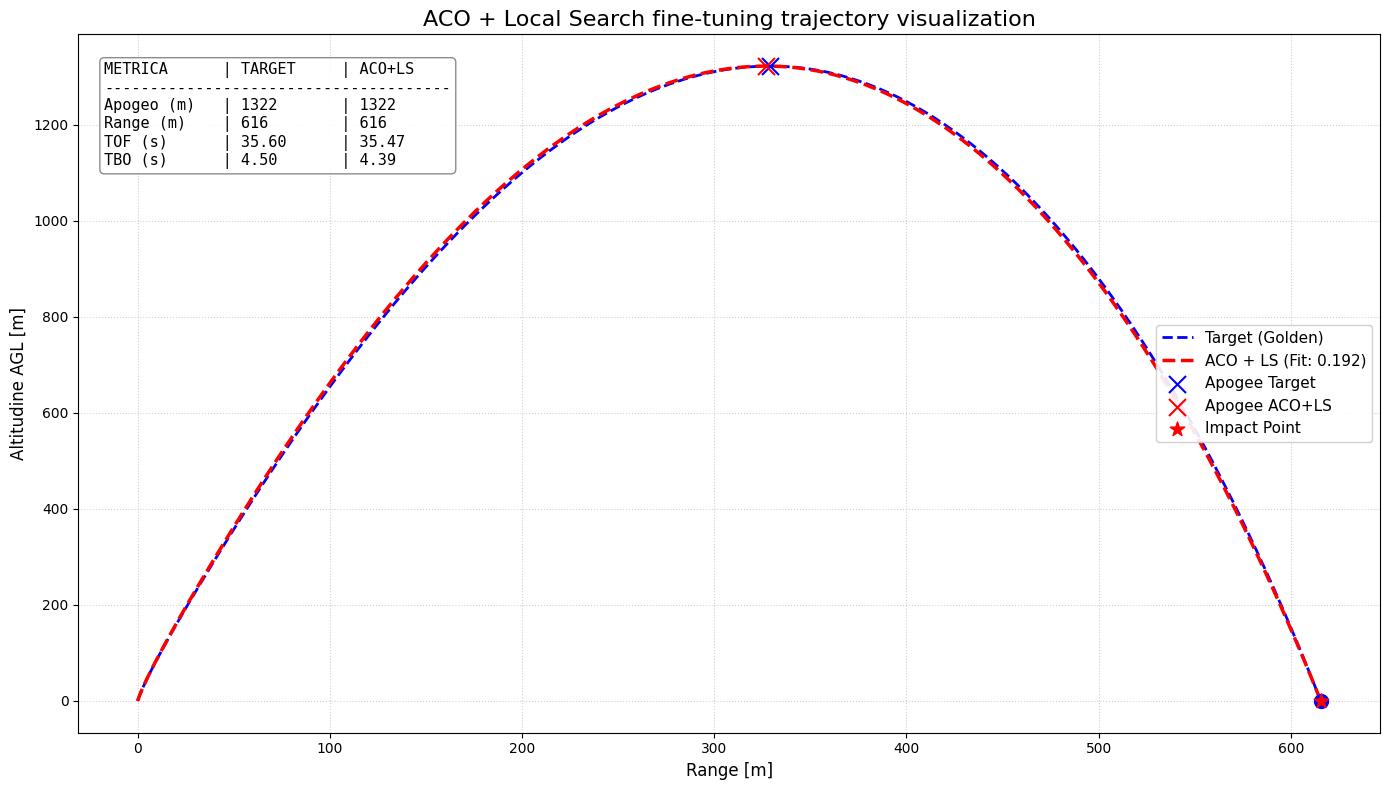

In [18]:
import matplotlib.pyplot as plt
import numpy as np

# --- 1. Recupero Dati Puntuali per la Tabella (ACO + LS) ---
# Target (Golden) - Già calcolati, ma li richiamiamo per sicurezza
val_tof_target = flight_golden.t_final
val_tbo_target = golden_params['burn_time']
val_apogee_target = np.max(z_golden)
val_range_target = r_golden[-1]

# Risultato (ACO + Local Search)
val_tof_ls = flight_ls.t_final
val_tbo_ls = ls_best_params['burn_time']
val_apogee_ls = np.max(z_ls)
val_range_ls = r_ls[-1]

# Coordinate Apogeo per il plot
idx_apogee_golden = np.argmax(z_golden)
xy_apogee_golden = (r_golden[idx_apogee_golden], val_apogee_target)

idx_apogee_ls = np.argmax(z_ls)
xy_apogee_ls = (r_ls[idx_apogee_ls], val_apogee_ls)

# --- 2. PLOT ---
plt.figure(figsize=(14, 8))

# Traiettorie
plt.plot(r_golden, z_golden, 'b--', linewidth=2, label='Target (Golden)')
plt.plot(r_ls, z_ls, 'r--', linewidth=2.5, label=f'ACO + LS (Fit: {ls_best_fitness:.3f})')

# --- Marker Apogeo ---
plt.scatter(*xy_apogee_golden, color='blue', s=150, marker='x', zorder=5, label='Apogee Target')
plt.scatter(*xy_apogee_ls, color='red', s=150, marker='x', zorder=5, label='Apogee ACO+LS')

# Annotazione Apogeo
#plt.annotate(f"{val_apogee_target:.0f}m", xy=xy_apogee_golden, xytext=(0, 10), 
             #textcoords="offset points", ha='center', color='blue')
#plt.annotate(f"{val_apogee_ls:.0f}m", xy=xy_apogee_ls, xytext=(0, 10), 
             #textcoords="offset points", ha='center', color='darkred')

# Marker Atterraggi
plt.scatter(val_range_target, 0, color='blue', s=100, marker='o', zorder=5)
plt.scatter(val_range_ls, 0, color='red', s=120, marker='*', zorder=5, label='Impact Point')

# --- INFO BOX (Tabella laterale) ---
stats_text = (
    f"{'METRICA':<12} | {'TARGET':<10} | {'ACO+LS':<10}\n"
    f"{'-'*38}\n"
    f"{'Apogeo (m)':<12} | {val_apogee_target:<10.0f} | {val_apogee_ls:<10.0f}\n"
    f"{'Range (m)':<12} | {val_range_target:<10.0f} | {val_range_ls:<10.0f}\n"
    f"{'TOF (s)':<12} | {val_tof_target:<10.2f} | {val_tof_ls:<10.2f}\n"
    f"{'TBO (s)':<12} | {val_tbo_target:<10.2f} | {val_tbo_ls:<10.2f}"
)

# Posizionamento Box
props = dict(boxstyle='round', facecolor='white', alpha=0.9, edgecolor='gray')
plt.text(0.02, 0.96, stats_text, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

# Decorazioni Grafico
plt.title("ACO + Local Search fine-tuning trajectory visualization", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitudine AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

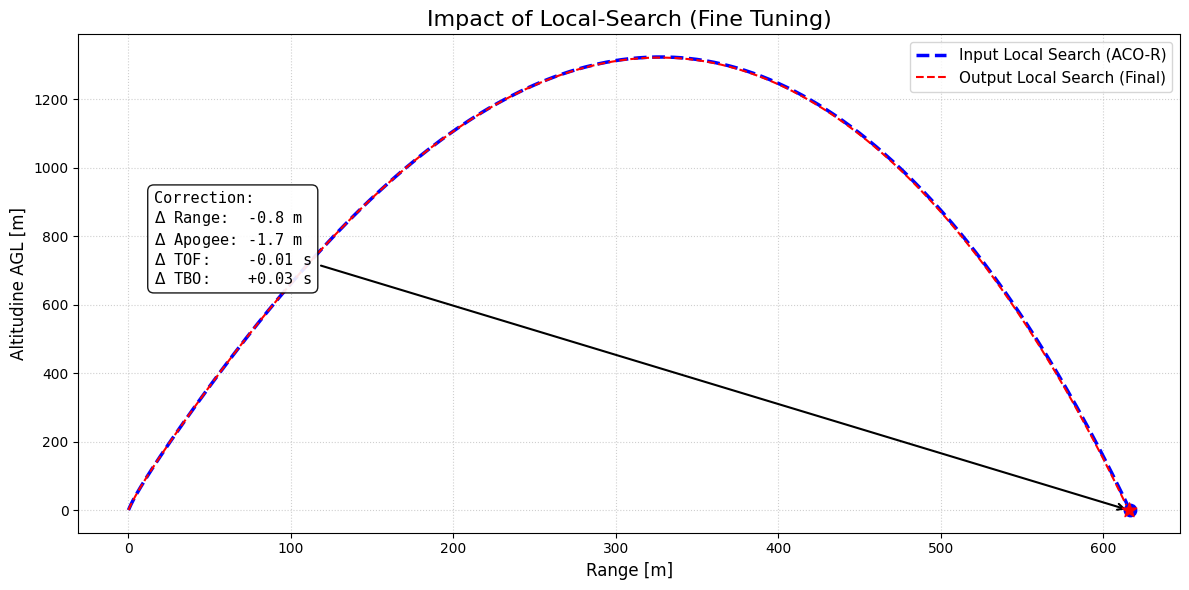

In [22]:
d_tof = flight_ls.t_final - flight_aco.t_final
d_tbo = ls_best_params['burn_time'] - aco_params['burn_time']

plt.figure(figsize=(12, 6))
plt.plot(r_aco, z_aco, color='blue', linestyle='--', linewidth=2.5, label='Input Local Search (ACO-R)')
plt.plot(r_ls, z_ls, 'r--', linewidth=1.5, label='Output Local Search (Final)')

plt.scatter(r_aco[-1], 0, color='blue', s=80, marker='o', zorder=5)
plt.scatter(r_ls[-1], 0, color='red', s=120, marker='*', zorder=5)


dx = r_ls[-1] - r_aco[-1]
dz_apogee = np.max(z_ls) - np.max(z_aco)

annotation_text = (
    f"Correction:\n"
    f"$\Delta$ Range:  {dx:+.1f} m\n"
    f"$\Delta$ Apogee: {dz_apogee:+.1f} m\n"
    f"$\Delta$ TOF:    {d_tof:+.2f} s\n"
    f"$\Delta$ TBO:    {d_tbo:+.2f} s"
)

plt.annotate(annotation_text, 
            xy=(r_ls[-1], 0), xytext=(r_ls[-1]-600, np.max(z_ls)/2),
            arrowprops=dict(facecolor='black', arrowstyle='->', lw=1.5),
            bbox=dict(boxstyle="round,pad=0.4", fc="white", ec="black", alpha=0.9),
            fontsize=11, family='monospace')

plt.title("Impact of Local-Search (Fine Tuning)", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitudine AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

In [25]:
data = []
param_keys = list(ls_best_params.keys())

for key in param_keys:
    val_golden = golden_params.get(key, 0.0)
    val_aco = aco_params.get(key, 0.0)
    val_ls = ls_best_params.get(key, 0.0)
    
    dev_perc = ((val_ls - val_golden) / val_golden) * 100 if val_golden != 0 else 0.0
        
    data.append({
        "Parameter": key,
        "Target": val_golden,
        "ACO Base": val_aco,
        "ACO + LS": val_ls,
        "Deviation %": dev_perc
    })

df_params = pd.DataFrame(data)
pd.options.display.float_format = '{:,.4f}'.format


display(df_params)

,Parameter,Target,ACO Base,ACO + LS,Deviation %
0,radius,0.0650,0.0601,0.0601,-7.5651
1,body_length,2.1000,2.1250,2.1257,1.2258
2,nose_length,0.6500,0.6371,0.6441,-0.9111
3,fin_span,0.1800,0.2491,0.2490,38.3484
4,fin_root_chord,0.3500,0.4502,0.4503,28.6580
5,fin_tip_chord,0.1200,0.1638,0.1643,36.9071
6,fin_sweep_angle,30.0000,37.5986,37.7994,25.9979
7,fin_distance_from_base,0.0000,0.0464,0.0468,0.0000
8,total_impulse,"3,200.0000","3,141.1985","3,142.6857",-1.7911
9,burn_time,4.5000,4.3665,4.3920,-2.3997


In [45]:
def draw_detailed_rocket_3d(params):
    """
    Advanced 3D visualization of the rocket including internal details:
    - Transparent fuselage
    - Motor Grain (internal)
    - External Nozzle
    - Payload (Warhead)
    - Center of Gravity (CG) marker

    The geometry and mass distribution logic replicates the RocketFactory class
    to ensure visual consistency with the physical model.
    """
    # ==========================================
    # 1. GEOMETRIC AND PHYSICAL LOGIC
    # ==========================================
    
    # --- Base Geometry ---
    r = params['radius']
    L_nose = params['nose_length']
    L_body = params['body_length']
    L_total = L_nose + L_body
    
    # --- Fins Geometry ---
    root_chord = params['fin_root_chord']
    tip_chord = params['fin_tip_chord']
    safe_tip_chord = min(tip_chord, root_chord)
    span = params['fin_span']
    sweep_angle = params['fin_sweep_angle']
    dist_base = params['fin_distance_from_base']
    
    # Derived calculations
    sweep_len = span * np.tan(np.radians(sweep_angle))
    fin_root_le_x = L_total - dist_base - root_chord
    
    # --- Motor and Nozzle ---
    grain_len = L_body * 0.4
    motor_x_start = L_total - grain_len
    motor_radius = r * 0.75
    
    # Nozzle geometry (derived from factory assumption)
    nozzle_exit_r = r * 0.35
    nozzle_base_r = r * 0.55
    nozzle_len = r * 1.2
    
    # --- Payload ---
    payload_x = L_nose * 0.5
    
    # --- CG Estimation (Simplified Factory Logic) ---
    rho = 2000.0; wall = 0.003
    
    # Component Masses and CGs
    m_nose = (np.pi * r * np.sqrt(r**2 + L_nose**2)) * wall * rho
    cg_nose = L_nose * 0.666
    
    m_body = (2 * np.pi * r * L_body) * wall * rho
    cg_body = L_nose + (L_body * 0.5)
    
    fin_area = (root_chord + safe_tip_chord) / 2 * span
    m_fins = (fin_area * 0.005 * 1800) * 4
    cg_fins = fin_root_le_x + (root_chord * 0.5)
    
    m_payload = 1.0
    
    # Motor Mass (Total at Liftoff)
    m_prop = params['total_impulse'] / (210 * 9.81)
    m_motor_tot = m_prop * 1.3
    cg_motor = L_total - (grain_len / 2)
    
    # System CG Calculation
    total_mass = m_nose + m_body + m_fins + m_payload + m_motor_tot
    total_moment = (m_nose*cg_nose + m_body*cg_body + m_fins*cg_fins + 
                    m_payload*payload_x + m_motor_tot*cg_motor)
    cg_pos = total_moment / total_mass

    # ==========================================
    # 2. 3D RENDERING
    # ==========================================
    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    # Mesh resolution
    N_radial = 40 
    theta = np.linspace(0, 2 * np.pi, N_radial)

    # --- A. FUSELAGE (Transparent) ---
    x_body = np.linspace(L_nose, L_total, 20)
    theta_g, x_g = np.meshgrid(theta, x_body)
    y_body = r * np.cos(theta_g)
    z_body = r * np.sin(theta_g)
    ax.plot_surface(x_g, y_body, z_body, color='azure', alpha=0.2, edgecolor='gray', linewidth=0.1)

    # --- B. NOSE CONE ---
    x_nose_arr = np.linspace(0, L_nose, 20)
    theta_gn, x_gn = np.meshgrid(theta, x_nose_arr)
    # Power series profile for aerodynamic look
    r_loc = r * (x_gn / L_nose)**0.75
    y_n = r_loc * np.cos(theta_gn)
    z_n = r_loc * np.sin(theta_gn)
    ax.plot_surface(x_gn, y_n, z_n, color='lightgray', alpha=0.6, edgecolor='none')

    # --- C. MOTOR GRAIN (Internal) ---
    x_mot = np.linspace(motor_x_start, L_total, 10)
    theta_gm, x_gm = np.meshgrid(theta, x_mot)
    y_mot = motor_radius * np.cos(theta_gm)
    z_mot = motor_radius * np.sin(theta_gm)
    ax.plot_surface(x_gm, y_mot, z_mot, color='firebrick', alpha=0.8, shade=True)

    # --- D. NOZZLE (External) ---
    x_noz = np.linspace(L_total, L_total + nozzle_len, 10)
    theta_noz, x_noz_grid = np.meshgrid(theta, x_noz)
    
    # Linear interpolation for conical nozzle shape
    pct = (x_noz_grid - L_total) / nozzle_len
    r_current_noz = nozzle_base_r * (1 - pct) + nozzle_exit_r * pct
    
    y_noz = r_current_noz * np.cos(theta_noz)
    z_noz = r_current_noz * np.sin(theta_noz)
    
    ax.plot_surface(x_noz_grid, y_noz, z_noz, color='#222222', alpha=1.0, shade=True)

    # --- E. PAYLOAD (Warhead) ---
    u, v = np.mgrid[0:2*np.pi:20j, 0:np.pi:10j]
    sphere_r = r * 0.6
    x_pay = payload_x + sphere_r * np.cos(u) * np.sin(v)
    y_pay = sphere_r * np.sin(u) * np.sin(v)
    z_pay = sphere_r * np.cos(v)
    ax.plot_surface(x_pay, y_pay, z_pay, color='limegreen', alpha=0.9)

    # --- F. FINS ---
    # Define fin points in 2D (x, r)
    p_root_le = np.array([fin_root_le_x, r])
    p_tip_le  = np.array([fin_root_le_x + sweep_len, r + span])
    p_tip_te  = np.array([fin_root_le_x + sweep_len + safe_tip_chord, r + span])
    p_root_te = np.array([fin_root_le_x + root_chord, r])
    
    fin_colors = ['darkred', 'red', 'darkred', 'red']
    
    # Rotate and place 4 fins
    for i, angle_deg in enumerate([0, 90, 180, 270]):
        rad = np.radians(angle_deg)
        c, s = np.cos(rad), np.sin(rad)
        
        # Rotation helper
        def rot(x, rd): return [x, rd*c, rd*s]

        pts = [rot(p[0], p[1]) for p in [p_root_le, p_tip_le, p_tip_te, p_root_te]]
        poly = Poly3DCollection([pts], alpha=0.9, facecolor=fin_colors[i], edgecolor='black')
        ax.add_collection3d(poly)

    # --- G. CG MARKER ---
    ax.scatter(cg_pos, 0, 0, color='black', s=200, marker='+', linewidth=3, label='Center of Gravity')
    # Vertical reference line for CG
    ax.plot([cg_pos, cg_pos], [0, 0], [0, r*2.5], 'k--', linewidth=1)
    ax.text(cg_pos, 0, r*2.8, "CG", color='black', fontsize=12, weight='bold', ha='center')

    # --- GRAPHICS SETUP ---
    ax.set_xlabel('Length (m)')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.set_title(f"3D ACO-R + LS optimized for single-trajectory Rocket Visualization \n(L={L_total:.2f}m, D={r*2*1000:.0f}mm)", fontsize=14)
    
    # Limits & Aspect Ratio
    limits = np.array([0, L_total + nozzle_len])
    max_range = np.ptp(limits)
    mid_x = np.mean(limits)
    
    ax.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax.set_ylim(-max_range/6, max_range/6)
    ax.set_zlim(-max_range/6, max_range/6)
    
    # Initial view angle
    ax.view_init(elev=20, azim=-60)
    
    # Enforce equal aspect ratio to avoid distortion
    ax.set_box_aspect((3, 1, 1))
    
    # Custom Legend
    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color='lightgray', lw=4, label='Fuselage'),
        Line2D([0], [0], color='firebrick', lw=4, label='Motor Grain'),
        Line2D([0], [0], color='black', lw=4, label='Nozzle'),
        Line2D([0], [0], color='limegreen', marker='o', lw=0, label='Payload'),
        Line2D([0], [0], color='black', marker='+', lw=0, markersize=10, label='CG')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    plt.show()

### Binary GA

In [28]:
try:
    from optimizer.binary_GA import BinaryGA
    print("BinaryGA module imported successfully.")
except ImportError:
    print("Error: BinaryGA module not found.")

print("\nStarting Benchmark Optimization (Binary GA)...")

# 1. CONFIGURATION AND INSTANTIATION
optimizer_ga = BinaryGA(ACO_PARAMS_FILE, CONSTRAINTS_FILE)

# 2. INITIALIZATION (GENERATION 0)
print(f"   Population Size: {optimizer_ga.pop_size}")
print(f"   Bits per Parameter: {optimizer_ga.bits_per_param}")
print("   Initializing Random Population...")

optimizer_ga.initialize(fitness_function)

# 3. BASELINE RETRIEVAL
_, best_fit_ga_start = optimizer_ga.get_best_solution()
print(f"   Best Random Start Fitness: {best_fit_ga_start:.4f}")

BinaryGA module imported successfully.

Starting Benchmark Optimization (Binary GA)...
   Population Size: 50
   Bits per Parameter: 16
   Initializing Random Population...
   Best Random Start Fitness: 29.9584


In [29]:
start_time_ga = time.time()

# Initialize counters
# The initial population evaluation consumes 'pop_size' function calls
call_counter_ga = optimizer_ga.pop_size 
generation = 0
best_fitness_history_ga = []

# ------------------------------------------------------------------------------
# MAIN OPTIMIZATION LOOP (BINARY GA)
# The loop continues until the computational budget (max_function_calls) is exhausted.
# ------------------------------------------------------------------------------
while call_counter_ga < max_calls:
    generation += 1
    
    # Execute one full generation (Selection -> Crossover -> Mutation -> Evaluation)
    current_best_fit = optimizer_ga.optimize_step(fitness_function)
    best_fitness_history_ga.append(current_best_fit)
    
    # Update function call counter
    # If elitism is enabled, the best individual is not re-evaluated, saving 1 call.
    # Otherwise, the entire population is evaluated.
    calls_in_gen = optimizer_ga.pop_size - 1 if optimizer_ga.elitism else optimizer_ga.pop_size
    call_counter_ga += calls_in_gen
    
    # Periodic logging
    if generation % 10 == 0:
        print(f"Gen: {generation:3d} | Calls: {call_counter_ga:5d} | Best: {current_best_fit:.4f}")

# ------------------------------------------------------------------------------
# RESULTS RETRIEVAL
# ------------------------------------------------------------------------------
ga_time = time.time() - start_time_ga
best_params_ga, best_score_ga = optimizer_ga.get_best_solution()

print(f"\nGA completed in {ga_time:.2f} s.")
print(f"GA Best Fitness: {best_score_ga:.4f}")

Gen:  10 | Calls:   540 | Best: 9.2355
Gen:  20 | Calls:  1030 | Best: 1.6032
Gen:  30 | Calls:  1520 | Best: 0.9845
Gen:  40 | Calls:  2010 | Best: 0.9284
Gen:  50 | Calls:  2500 | Best: 0.8620
Gen:  60 | Calls:  2990 | Best: 0.8620
Gen:  70 | Calls:  3480 | Best: 0.8594
Gen:  80 | Calls:  3970 | Best: 0.8491

GA completed in 1070.90 s.
GA Best Fitness: 0.8491


In [30]:
rocket_ga = factory.create_rocket(best_params_ga)

print("\n Rocket Simulation GA...")
flight_ga = Flight(
    rocket=rocket_ga,
    environment=evaluator.env,
    rail_length=factory.rail_length,
    inclination=best_params_ga['launch_angle'],
    heading=90,
    terminate_on_apogee=False
)

r_ga = get_range_profile(flight_ga)
z_ga = flight_ga.z[:, 1] - evaluator.env.elevation

print(f"   GA Apogee: {flight_ga.apogee - evaluator.env.elevation:.2f} m")
print(f"   GA Range:  {r_ga[-1]:.2f} m")


 Rocket Simulation GA...
   GA Apogee: 1322.20 m
   GA Range:  615.69 m


In [31]:
print("\n" + "="*50)
print(f"OPTIMIZATION RESULTS BINARY GA")
print("="*50)
print(f"Final Fitness : {best_score_ga:.6f}")
print("-" * 50)
print(f"{'PARAMETER':<25} | {'VALUE':<15}")
print("-" * 50)

for key, val in best_params_ga.items():
    print(f"{key:<25} | {val:.4f}")

print("="*50)


OPTIMIZATION RESULTS BINARY GA
Final Fitness : 0.849071
--------------------------------------------------
PARAMETER                 | VALUE          
--------------------------------------------------
radius                    | 0.0703
body_length               | 1.9495
nose_length               | 0.4516
fin_span                  | 0.2422
fin_root_chord            | 0.2943
fin_tip_chord             | 0.1505
fin_sweep_angle           | 14.0658
fin_distance_from_base    | 0.0336
total_impulse             | 3324.6052
burn_time                 | 3.9531
launch_angle              | 84.6795


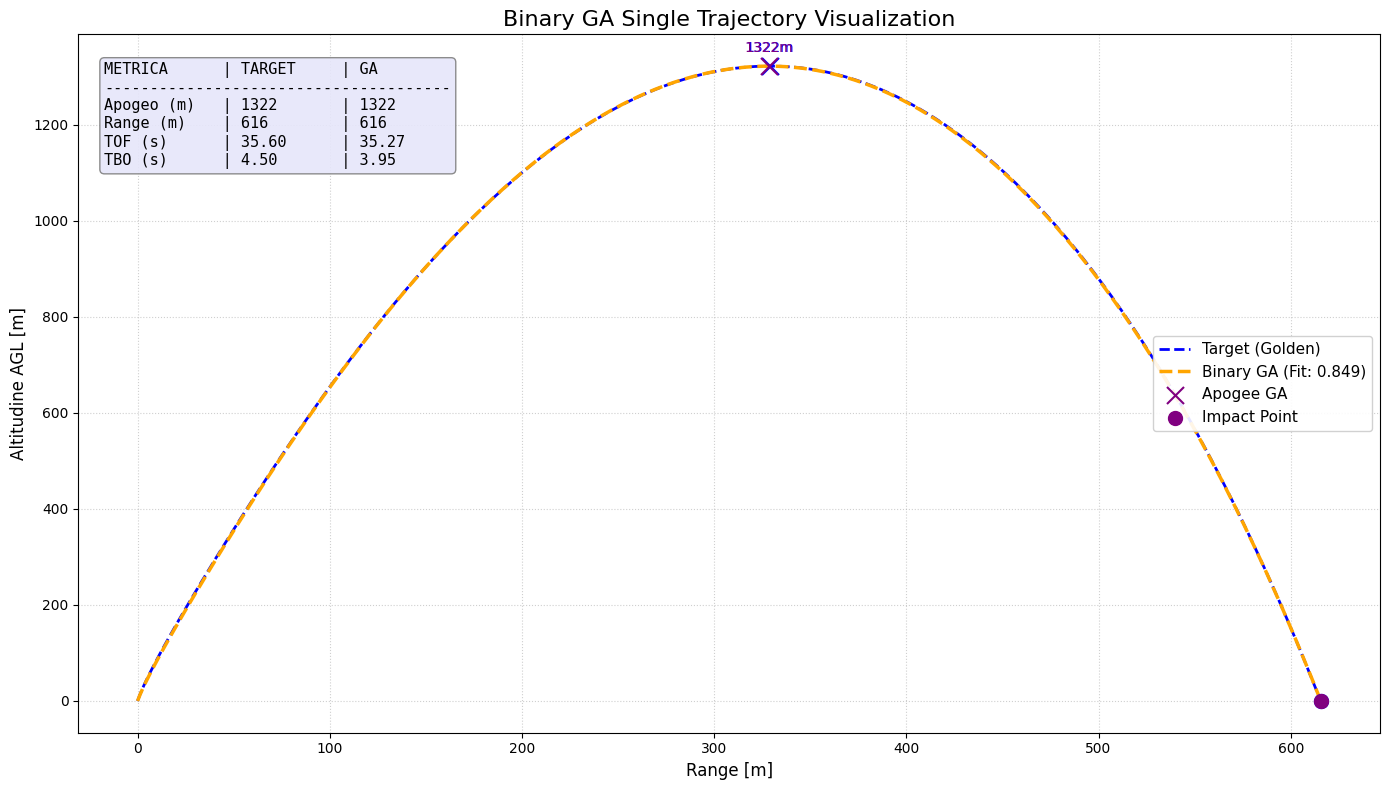

In [32]:
rocket_ga = factory.create_rocket(best_params_ga)
flight_ga = Flight(
    rocket=rocket_ga,
    environment=evaluator.env,
    rail_length=factory.rail_length,
    inclination=best_params_ga['launch_angle'],
    heading=90,
    terminate_on_apogee=False
)

r_ga = np.sqrt(flight_ga.x[:, 1]**2 + flight_ga.y[:, 1]**2)
z_ga = flight_ga.z[:, 1] - evaluator.env.elevation

val_tof_ga = flight_ga.t_final
val_tbo_ga = best_params_ga['burn_time']
val_apogee_ga = np.max(z_ga)
val_range_ga = r_ga[-1]

val_tof_target = flight_golden.t_final
val_tbo_target = golden_params['burn_time']
val_apogee_target = np.max(z_golden)
val_range_target = r_golden[-1]

idx_apogee_ga = np.argmax(z_ga)
xy_apogee_ga = (r_ga[idx_apogee_ga], val_apogee_ga)
idx_apogee_golden = np.argmax(z_golden)
xy_apogee_golden = (r_golden[idx_apogee_golden], val_apogee_target)

# ---  PLOT ---
plt.figure(figsize=(14, 8))

plt.plot(r_golden, z_golden, 'b--', linewidth=2, label='Target (Golden)')
plt.plot(r_ga, z_ga, color='orange', linestyle='--', linewidth=2.5, label=f'Binary GA (Fit: {best_score_ga:.3f})')

plt.scatter(*xy_apogee_golden, color='blue', s=150, marker='x', zorder=5)
plt.scatter(*xy_apogee_ga, color='purple', s=150, marker='x', zorder=5, label='Apogee GA')
plt.annotate(f"{val_apogee_target:.0f}m", xy=xy_apogee_golden, xytext=(0, 10), 
             textcoords="offset points", ha='center', color='blue')
plt.annotate(f"{val_apogee_ga:.0f}m", xy=xy_apogee_ga, xytext=(0, 10), 
             textcoords="offset points", ha='center', color='purple')
plt.scatter(val_range_target, 0, color='blue', s=100, marker='o', zorder=5)
plt.scatter(val_range_ga, 0, color='purple', s=100, marker='o', zorder=5, label='Impact Point')


stats_text = (
    f"{'METRICA':<12} | {'TARGET':<10} | {'GA':<10}\n"
    f"{'-'*38}\n"
    f"{'Apogeo (m)':<12} | {val_apogee_target:<10.0f} | {val_apogee_ga:<10.0f}\n"
    f"{'Range (m)':<12} | {val_range_target:<10.0f} | {val_range_ga:<10.0f}\n"
    f"{'TOF (s)':<12} | {val_tof_target:<10.2f} | {val_tof_ga:<10.2f}\n"
    f"{'TBO (s)':<12} | {val_tbo_target:<10.2f} | {val_tbo_ga:<10.2f}"
)

props = dict(boxstyle='round', facecolor='lavender', alpha=0.9, edgecolor='gray')
plt.text(0.02, 0.96, stats_text, transform=plt.gca().transAxes, fontsize=11,
        verticalalignment='top', bbox=props, fontfamily='monospace')

plt.title("Binary GA Single Trajectory Visualization", fontsize=16)
plt.xlabel("Range [m]", fontsize=12)
plt.ylabel("Altitudine AGL [m]", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='center right', fontsize=11, framealpha=0.9)

plt.tight_layout()
plt.show()

## Final comparison 

In [ ]:
import pandas as pd
import numpy as np

# ------------------------------------------------------------------------------
# 1. DATA PREPARATION
# ------------------------------------------------------------------------------

# GA Random Initialization Data 
ga_random_start_params = _
# --- Calculate Error Residuals (Target vs Achieved) ---

# 1. ACO-R (Global Search Phase)
err_range_aco = abs(val_range_target - val_range_aco)
err_apogee_aco = abs(val_apogee_target - val_apogee_aco)
err_tof_aco = abs(val_tof_target - val_tof_aco)
err_tbo_aco = abs(val_tbo_target - val_tbo_aco)

# 2. ACO + LS (Hybrid / Fine-Tuning Phase)
err_range_ls = abs(val_range_target - val_range_ls)
err_apogee_ls = abs(val_apogee_target - val_apogee_ls)
err_tof_ls = abs(val_tof_target - val_tof_ls)
err_tbo_ls = abs(val_tbo_target - val_tbo_ls)

# 3. Binary GA (Benchmark)
err_range_ga = abs(val_range_target - val_range_ga)
err_apogee_ga = abs(val_apogee_target - val_apogee_ga)
err_tof_ga = abs(val_tof_target - val_tof_ga)
err_tbo_ga = abs(val_tbo_target - val_tbo_ga)

# Calculate Cumulative Execution Time for Hybrid approach
total_time_ls = execution_time + ls_time

# ------------------------------------------------------------------------------
# 2. TABLE 1: ALGORITHM PERFORMANCE METRICS
# Aggregates fitness, execution time, and physical errors.
# ------------------------------------------------------------------------------
perf_data = [
    {
        "Algorithm": "ACO-R (Base)",
        "Exec Time (s)": execution_time,
        "Best Fitness": aco_best_fitness,
        "Range Err (m)": err_range_aco,
        "Apogee Err (m)": err_apogee_aco,
        "TOF Err (s)": err_tof_aco,
        "TBO Err (s)": err_tbo_aco
    },
    {
        "Algorithm": "ACO-R + LS (Hybrid)",
        "Exec Time (s)": total_time_ls,
        "Best Fitness": ls_best_fitness,
        "Range Err (m)": err_range_ls,
        "Apogee Err (m)": err_apogee_ls,
        "TOF Err (s)": err_tof_ls,
        "TBO Err (s)": err_tbo_ls
    },
    {
        "Algorithm": "Binary GA",
        "Exec Time (s)": ga_time,
        "Best Fitness": best_score_ga,
        "Range Err (m)": err_range_ga,
        "Apogee Err (m)": err_apogee_ga,
        "TOF Err (s)": err_tof_ga,
        "TBO Err (s)": err_tbo_ga
    }
]

df_perf = pd.DataFrame(perf_data)

# ------------------------------------------------------------------------------
# 3. TABLE 2: PHYSICAL PARAMETER COMPARISON
# Compares the design variables across:
# - Target (Golden Rocket)
# - Random Initializations (ACO & GA)
# - Final Optimized Solutions (ACO, ACO+LS, GA)
# ------------------------------------------------------------------------------
param_data = []
param_keys = list(golden_params.keys())

# Ensure random_best_params is available (fallback if not defined in previous cells)
if 'random_best_params' not in locals():
    random_best_params = {}

for key in param_keys:
    row = {
        "Parameter": key,
        "Target (Golden)": golden_params.get(key),
        "Random Start (ACO-R)": random_best_params.get(key, 0.0),
        "Optimized (ACO-R)": aco_params.get(key),
        "ACO-R + LS": ls_best_params.get(key),
        "Random Start (GA)": ga_random_start_params.get(key, 0.0), # Added
        "Optimized (GA)": best_params_ga.get(key)
    }
    param_data.append(row)

df_params_final = pd.DataFrame(param_data)

# ------------------------------------------------------------------------------
# 4. VISUALIZATION AND EXPORT
# ------------------------------------------------------------------------------
pd.options.display.float_format = '{:,.4f}'.format

print("\n" + "="*80)
print(f"TABLE 1: ALGORITHM PERFORMANCE COMPARISON (Single Trajectory)")
print("="*80)
display(df_perf)
#df_perf.to_csv("../results/single_trajectory/final_performance_single.csv", index=False)

print("\n" + "="*80)
print(f"TABLE 2: DESIGN PARAMETER CONVERGENCE")
print("="*80)
display(df_params_final)
#df_params_final.to_csv("../results/single_trajectory/single_trajectory_parameters.csv", index=False)


TABLE 1: ALGORITHM PERFORMANCE COMPARISON (Single Trajectory)


,Algorithm,Exec Time (s),Best Fitness,Range Err (m),Apogee Err (m),TOF Err (s),TBO Err (s)
0,ACO-R (Base),449.6031,0.4651,0.8018,1.7305,0.1284,0.1335
1,ACO-R + LS (Hybrid),573.9021,0.1924,0.0002,0.0003,0.1344,0.1080
2,Binary GA,"1,070.8993",0.8491,0.0765,0.1391,0.3306,0.5469



TABLE 2: DESIGN PARAMETER CONVERGENCE


,Parameter,Target (Golden),Random Start (ACO-R),Optimized (ACO-R),ACO-R + LS,Random Start (GA),Optimized (GA)
0,radius,0.0650,0.0634,0.0601,0.0601,0.0725,0.0703
1,body_length,2.1000,2.3840,2.1250,2.1257,1.5357,1.9495
2,nose_length,0.6500,0.5497,0.6371,0.6441,0.6987,0.4516
3,fin_span,0.1800,0.1556,0.2491,0.2490,0.1934,0.2422
4,fin_root_chord,0.3500,0.4438,0.4502,0.4503,0.2483,0.2943
5,fin_tip_chord,0.1200,0.2394,0.1638,0.1643,0.0512,0.1505
6,fin_sweep_angle,30.0000,44.5100,37.5986,37.7994,39.5830,14.0658
7,fin_distance_from_base,0.0000,0.0377,0.0464,0.0468,0.0332,0.0336
8,total_impulse,"3,200.0000","3,128.7788","3,141.1985","3,142.6857","2,631.4488","3,324.6052"
9,burn_time,4.5000,2.3340,4.3665,4.3920,2.1182,3.9531


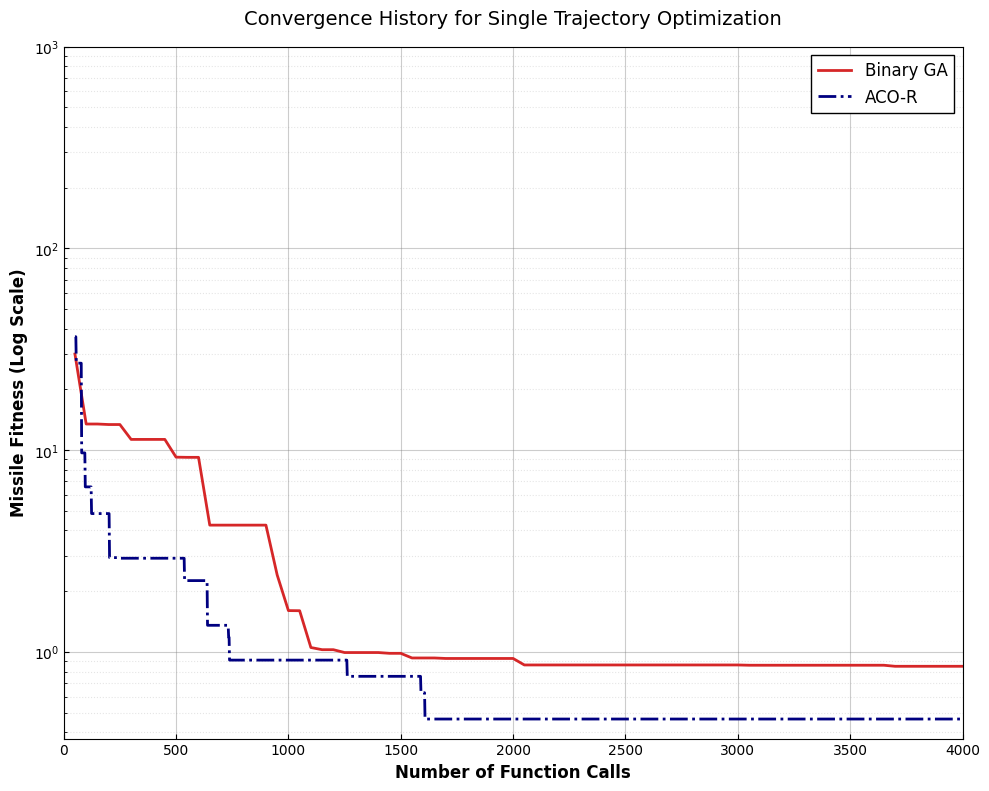

In [38]:
k_aco = 50   
m_aco = 2    
pop_ga = 50  
TARGET_CALLS = 4000

y_aco = np.array(best_fitness_history)
y_ga = np.array(best_fitness_history_ga)
x_aco = np.arange(len(y_aco)) * m_aco + k_aco
x_ga = np.arange(len(y_ga)) * pop_ga + pop_ga


if x_aco[-1] < TARGET_CALLS:
    x_aco = np.append(x_aco, TARGET_CALLS) 
    y_aco = np.append(y_aco, y_aco[-1])    

if x_ga[-1] < TARGET_CALLS:
    x_ga = np.append(x_ga, TARGET_CALLS)
    y_ga = np.append(y_ga, y_ga[-1])

plt.figure(figsize=(10, 8))
plt.semilogy(x_ga, y_ga, color='#d62728', linestyle='-', linewidth=2, label='Binary GA')
plt.semilogy(x_aco, y_aco, color='#000080', linestyle='-.', linewidth=2, label='ACO-R')
plt.xlim(0, TARGET_CALLS)


y_min = min(np.min(y_aco), np.min(y_ga))
y_max = 1000 

plt.ylim(y_min * 0.8, y_max)
plt.xlabel('Number of Function Calls', fontsize=12, fontweight='bold')
plt.ylabel('Missile Fitness (Log Scale)', fontsize=12, fontweight='bold')
plt.title('Convergence History for Single Trajectory Optimization', fontsize=14, y=1.02)
plt.grid(True, which="major", ls="-", alpha=0.4, color='gray')
plt.grid(True, which="minor", ls=":", alpha=0.2, color='gray')
plt.legend(frameon=True, fancybox=False, edgecolor='black', framealpha=1, 
           loc='upper right', fontsize=12)
plt.tick_params(axis='both', direction='in', which='both', labelsize=10)
plt.tight_layout()
plt.show()

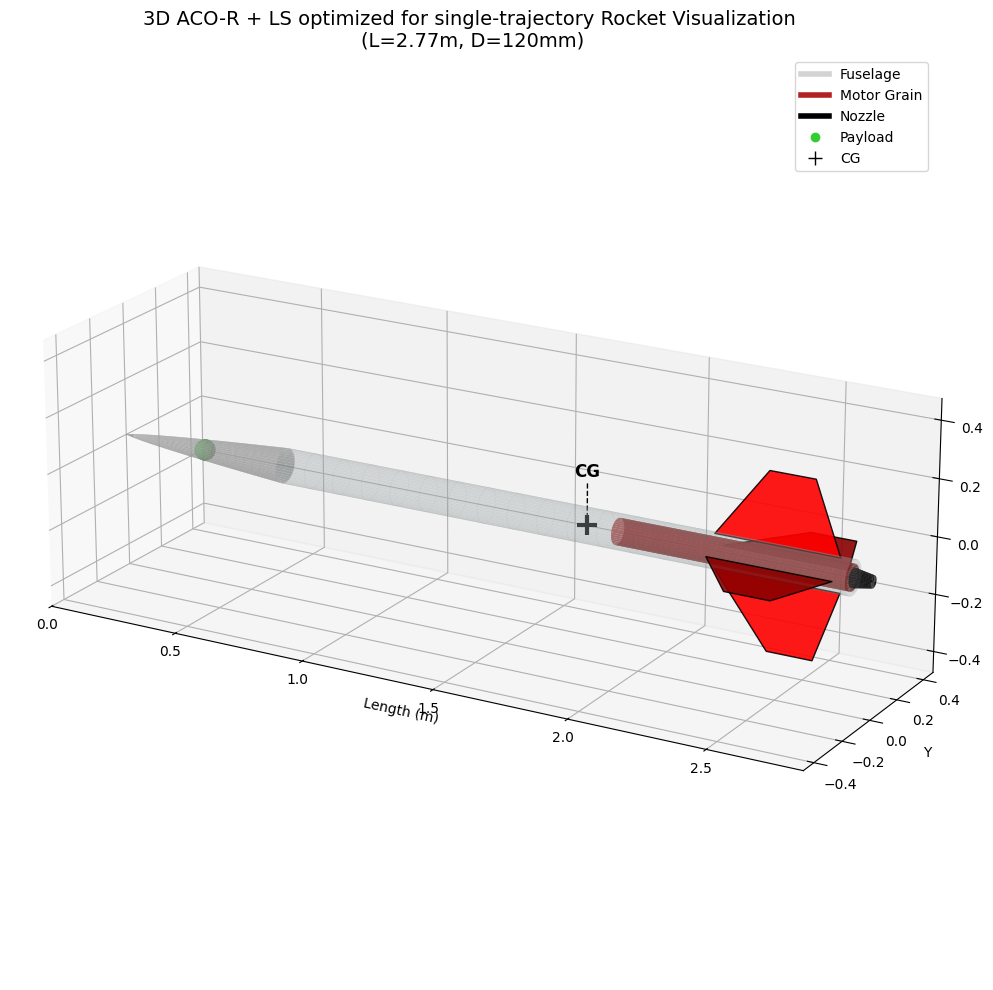

In [46]:
#draw_detailed_rocket_3d(golden_params)
#draw_detailed_rocket_3d(aco_params)
draw_detailed_rocket_3d(ls_best_params)
#draw_detailed_rocket_3d(best_params_ga)